Código adaptado de:

[1] D. Foster, Generative Deep Learning: Teaching Machines to Paint, Write, Compose, and Play, Second Edition, O'Reilly, 2023.

# Laboratório 5: Modelos auto-regressivos (utilizando  RNNs)

Em um modelo auto-regressivo, a probabilidade de uma sequência é fatorada como:

$
p(x_1, x_2, \ldots, x_T)=\prod\limits_{t=1}^{T} p(x_t \mid x_1, \ldots, x_{t-1})
$

**Exemplo.** Para a sequência `recipe for cake`, o modelo aprende:
- predizer `for` dado `recipe`;
- predizer `cake` dado `recipe for`.

O fluxo geral será:

1. carregar receitas em texto;
2. transformar palavras em IDs inteiros;
3. treinar uma LSTM para predizer o próximo token;
4. gerar novas receitas por amostragem auto-regressiva.

## 1. Bibliotecas

Nesta seção, instalamos e importamos as bibliotecas necessárias para manipulação de texto, construção de datasets, definição da rede recorrente, treinamento, visualização e geração de texto.

A célula a seguir instala a biblioteca `torchinfo`, usada para exibir um resumo da arquitetura da rede neural em PyTorch.

Ela é útil para verificar, por exemplo:
- shapes de entrada e saída;
- número de parâmetros;
- camadas treináveis.

In [1]:
!pip install torchinfo

In [ ]:
import os                                           # módulo para interagir com o sistema de arquivos (criar pastas, ler arquivos, etc.)
import json                                         # para carregar e salvar dados em formato JSON
import re                                           # expressões regulares para manipulação e validação de strings
import string                                       # utilitários para strings (como lista de pontuações, letras, etc.)
from collections import Counter                     # estrutura de dados para contagem rápida de itens
import numpy as np                                  # biblioteca para cálculo numérico e operações com arrays
import torch                                        # PyTorch: framework de aprendizado profundo
import torch.nn as nn                               # módulos de construção de redes neurais (camadas, funções de perda, etc.)
from torch.utils.data import Dataset, DataLoader    # abstrações para datasets e carregamento de dados (batching, shuffle)
import torch.nn.functional as F                     # funções de ativação, perda e utilitários funcionais
from torchinfo import summary                       # para exibir o resumo ("summary") da arquitetura do modelo em PyTorch
from tqdm.auto import tqdm                          # barra de progresso adaptada ao ambiente (notebook/terminal) para loops longos
from torch.utils.data import random_split           # utilitário para dividir um Dataset em subconjuntos (ex.: treinamento/teste)
import matplotlib.pyplot as plt                     # biblioteca para gerar gráficos (ex.: curva de perda por época)
import gdown                                        # utilitário para baixar arquivos do Google Drive via link público

In [4]:
# Verificação da versão do PyTorch
print(f'Versão do pytorch: {torch.__version__}.')  # exibe a versão instalada do PyTorch

Versão do pytorch: 2.13.0.


In [11]:
import inspect
# Verificação da versão do `gdown`
print(gdown.__version__)   # exibe a versão instalada do gdown
print(inspect.signature(gdown.download))

6.4.0
(url: str | None = None, output: str | BinaryIO | None = None, quiet: bool = False, proxy: str | None = None, speed: float | None = None, use_cookies: bool = True, verify: bool | str = True, id: str | None = None, resume: bool = False, format: str | None = None, user_agent: str | None = None, log_messages: dict[str, str] | None = None, progress: collections.abc.Callable[[int, int | None], None] | None = None, skip_download: bool = False, cookies_file: str | None = None, hasher: 'hashlib._Hash | None' = None, timeout: float | tuple[float, float] | None = None, retries: int = 0, cancel: threading.Event | None = None) -> str | BinaryIO | gdown.download.GoogleDriveFileToDownload


In [6]:
# Configurações do Jupyter/Colab: O comando `%matplotlib inline` faz com que os gráficos do `matplotlib` sejam exibidos diretamente dentro do notebook.
%matplotlib inline

## 2. Hiperparâmetros

Nesta seção, definimos os principais hiperparâmetros do experimento. Eles controlam o tamanho do vocabulário, o comprimento das sequências, a arquitetura da rede e o processo de treinamento.

### Definição dos hiperparâmetros

A célula a seguir define os valores usados no treinamento da LSTM.

Os principais hiperparâmetros são:

| Parâmetro | Descrição |
|---|---|
| `VOCAB_SIZE` | Número máximo de tokens no vocabulário |
| `MAX_LEN` | Comprimento máximo da sequência de entrada |
| `EMBEDDING_DIM` | Dimensão dos vetores de palavras |
| `N_UNITS` | Tamanho do estado oculto da LSTM |
| `BATCH_SIZE` | Número de exemplos por lote |
| `EPOCHS` | Número de passadas pelo conjunto de treinamento |
| `LEARNING_RATE` | Passo usado pelo otimizador |

**Exemplo.** Se `MAX_LEN = 200`, cada exemplo de treinamento terá 200 tokens de entrada. O alvo também terá 200 tokens, mas deslocado uma posição para representar o "próximo token".

In [7]:
VOCAB_SIZE    = 10_000  # tamanho máximo do vocabulário (número de tokens distintos considerados)
MAX_LEN       = 200     # comprimento máximo de cada sequência de entrada (número de tokens)
EMBEDDING_DIM = 100     # dimensão dos vetores de embedding que representam cada token
N_UNITS       = 128     # número de unidades (neurônios) na camada recorrente (LSTM/GRU/RNN)
BATCH_SIZE    = 32      # tamanho do lote (batch) usado em cada atualização de gradiente
EPOCHS        = 25      # número de épocas de treinamento (passadas completas pelo conjunto de treino)
LEARNING_RATE = 1e-3    # taxa de aprendizado do otimizador (passo de atualização dos parâmetros)
DEVICE = (              # dispositivo de computação: tipo de acelerador (GPU/MPS) se disponível, caso contrário "cpu"
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)

In [8]:
print(f'Dispositivo: {DEVICE}')  # Exibe qual dispositivo está sendo usado

Dispositivo: mps


## 3. Dados: [Epicurious - Recipes with Rating and Nutrition](https://www.kaggle.com/datasets/hugodarwood/epirecipes)

O laboratório utiliza a base de receitas do Epicurious, contendo títulos, instruções e outros metadados. Para modelagem auto-regressiva, vamos usar principalmente texto: título + modo de preparo.

A tarefa do modelo generativo será aprender padrões linguísticos do corpus, por exemplo:

```text
    Recipe for roasted vegetables | preheat oven ...
```

A partir desse padrão, o modelo poderá continuar uma receita token por token.

### Baixa os dados

Nesta etapa, baixamos o arquivo JSON (`full_format_recipes.json`) com as receitas, caso ele ainda não exista no ambiente do Colab.

Essa verificação evita baixar o mesmo arquivo repetidamente durante a execução do notebook.

In [14]:
url = 'https://drive.google.com/file/d/1gzDjjou1lbCU87H_rDg5mhAJlkqTTqgn/view?usp=sharing'  # URL pública do arquivo no Google Drive
os.makedirs("name=data/", exist_ok=True)
output = 'data/full_format_recipes.json'                                                         # nome do arquivo local onde o JSON será salvo
if not os.path.isfile(output):                                                              # verifica se o arquivo ainda não existe no diretório atual
    print(f"Arquivo '{output}' não encontrado. Fazendo download...")                        # informa que o download será realizado
    gdown.download(
        url=url, 
        output=output, 
        quiet=False, 
#        fuzzy=True           # Elimina o parametro pois na versao que tenho instalado não existe mais
    )                         # baixa o arquivo do Google Drive para o caminho especificado
else:
    print(f"Arquivo '{output}' já existe. Pulando download.")                               # informa que o arquivo já existe e evita novo download

Arquivo 'data/full_format_recipes.json' já existe. Pulando download.


### Carrega os dados

Cada receita é representada como um dicionário Python com campos como título, ingredientes, instruções e metadados nutricionais.

In [15]:
with open(output) as json_data:           # abre o arquivo JSON de receitas em modo leitura
    recipe_data = json.load(json_data)    # carrega o conteúdo do arquivo como uma lista de dicionários

In [16]:
print(f'tipo de recipe_data:         {type(recipe_data)}')      # mostra o tipo da variável recipe_data (list)
print(f'tipo de recipe_data[indice]: {type(recipe_data[0])}')   # mostra o tipo de um elemento de recipe_data (dict)

tipo de recipe_data:         <class 'list'>
tipo de recipe_data[indice]: <class 'dict'>


### Inspeciona os dados

Antes de processar o corpus, é importante olhar a estrutura de uma receita. Essa inspeção mostra quais chaves existem e quais campos serão utilizados para a tarefa de geração de texto no nosso laboratório.

A célula abaixo percorre os pares `chave: valor` da primeira receita e imprime seu conteúdo.

Isso permite verificar campos disponíveis, como `title`, `directions`, `ingredients` e outros metadados.

In [17]:
for k, v in recipe_data[0].items():  # percorre todos os pares (chave, valor) do primeiro dicionário de receita
    print(f'{k}: {v}')               # imprime cada chave e seu valor para inspecionar a estrutura dos dados

directions: ['1. Place the stock, lentils, celery, carrot, thyme, and salt in a medium saucepan and bring to a boil. Reduce heat to low and simmer until the lentils are tender, about 30 minutes, depending on the lentils. (If they begin to dry out, add water as needed.) Remove and discard the thyme. Drain and transfer the mixture to a bowl; let cool.', '2. Fold in the tomato, apple, lemon juice, and olive oil. Season with the pepper.', '3. To assemble a wrap, place 1 lavash sheet on a clean work surface. Spread some of the lentil mixture on the end nearest you, leaving a 1-inch border. Top with several slices of turkey, then some of the lettuce. Roll up the lavash, slice crosswise, and serve. If using tortillas, spread the lentils in the center, top with the turkey and lettuce, and fold up the bottom, left side, and right side before rolling away from you.']
fat: 7.0
date: 2006-09-01T04:00:00.000Z
categories: ['Sandwich', 'Bean', 'Fruit', 'Tomato', 'turkey', 'Vegetable', 'Kid-Friendly',

### Filtra os dados

Nesta etapa, selecionamos apenas receitas que possuem título e instruções válidas. Em seguida, cada receita é transformada em uma única string.


A célula a seguir cria `filtered_data`, uma lista de textos. Cada item combina o título da receita com suas instruções:

```text
    Recipe for <título> | <instrução 1> <instrução 2> ...
```

O símbolo `|` atua como separador entre título e modo de preparo.

**Exemplo:** Se a receita for:

```python
    title = "Chocolate Cake"
    directions = ["Mix flour.", "Bake for 30 minutes."]
```

o texto final será:

```text
    Recipe for Chocolate Cake | Mix flour. Bake for 30 minutes.
```


In [18]:
filtered_data = [                                                   # lista de strings (uma por receita) que será usada como corpus de texto
    "Recipe for " + x["title"] + " | " + " ".join(x["directions"])  # monta um texto único: título + '|' + instruções concatenadas
    for x in recipe_data                                            # percorre cada dicionário de receita carregado do JSON original
    if "title" in x                                                 # garante que a chave "title" existe no dicionário
    and x["title"] is not None                                      # garante que o título não é nulo
    and "directions" in x                                           # garante que a chave "directions" existe no dicionário
    and x["directions"] is not None                                 # garante que as instruções não são nulas
]

### Conta o número de receitas

Após a filtragem, contamos quantas receitas válidas (receitas com título e instruções válidas) serão usadas no experimento. Esse número define o tamanho do corpus disponível para treinar o modelo.

In [19]:
n_recipes = len(filtered_data)                 # conta quantas receitas válidas foram filtradas para o corpus
print(f"{n_recipes} receitas carregadas.")     # exibe na tela o número total de receitas carregadas

20111 receitas carregadas.


### Mostra um exemplo

Esta célula seleciona a primeira receita processada em `filtered_data` e imprime seu texto completo. Essa inspeção ajuda a confirmar se título, separador e instruções foram concatenados corretamente.

In [20]:
exemplo = filtered_data[0]  # seleciona a primeira receita filtrada como exemplo de texto bruto
print(exemplo)              # imprime o texto dessa receita para inspeção visual

Recipe for Lentil, Apple, and Turkey Wrap  | 1. Place the stock, lentils, celery, carrot, thyme, and salt in a medium saucepan and bring to a boil. Reduce heat to low and simmer until the lentils are tender, about 30 minutes, depending on the lentils. (If they begin to dry out, add water as needed.) Remove and discard the thyme. Drain and transfer the mixture to a bowl; let cool. 2. Fold in the tomato, apple, lemon juice, and olive oil. Season with the pepper. 3. To assemble a wrap, place 1 lavash sheet on a clean work surface. Spread some of the lentil mixture on the end nearest you, leaving a 1-inch border. Top with several slices of turkey, then some of the lettuce. Roll up the lavash, slice crosswise, and serve. If using tortillas, spread the lentils in the center, top with the turkey and lettuce, and fold up the bottom, left side, and right side before rolling away from you.


## 4. Tokenização e criação do conjunto de dados processado

Nesta seção, transformamos texto em tensores numéricos. Redes neurais não processam palavras diretamente; elas recebem IDs inteiros, que depois são convertidos em embeddings.

O processamento inclui:

1. normalizar pontuação e caixa;
2. construir vocabulário;
3. converter tokens em IDs;
4. aplicar padding ou truncamento;
5. criar pares entrada-alvo para prever o próximo token.

### Classe `EpicuriousRecipesDataset`

A célula a seguir define um `Dataset` PyTorch para modelagem auto-regressiva de texto.

A classe realiza quatro operações principais:

1. **normalização:** coloca texto em minúsculas e separa pontuação;
2. **vocabulário:** mantém os tokens mais frequentes e reserva `<PAD>` e `<UNK>`;
3. **codificação:** converte tokens para IDs inteiros;
4. **deslocamento temporal:** gera pares `(x, y)`, em que `y` é `x` deslocado um token à frente.

A lógica de treinamento é:

$$
x = [t_0,t_1,t_2,\ldots,t_{L-1}], \qquad
y = [t_1,t_2,t_3,\ldots,t_L].
$$

Assim, em cada posição, o modelo recebe o contexto anterior e aprende a predizer o próximo token.

**Exemplo.** Suponha a sequência de IDs:

```python
    seq = [12, 7, 51, 9, 4]
```

O dataset retorna:

```python
    x = [12, 7, 51, 9]
    y = [7, 51, 9, 4]
```

Portanto, quando a entrada atual contém `12`, o alvo correspondente é `7`; quando a entrada contém `12, 7`, o próximo token esperado é `51`.

In [21]:
class EpicuriousRecipesDataset(Dataset):
    """
    Dataset de receitas do Epicurious para modelagem auto-regressiva.

    Esta classe:
    - normaliza e tokeniza textos de receitas (título + instruções),
    - constrói um vocabulário limitado ao `vocab_size` mais frequentes,
    - codifica cada texto como uma sequência fixa de IDs (com padding/truncamento),
    - fornece pares (x, y) para treinamento auto-regressivo, com y deslocado em 1 token.

    Parameters
    ----------
    texts : list of str
        Lista de textos brutos de entrada (uma string por receita).
    vocab_size : int, optional
        Tamanho máximo do vocabulário (incluindo os tokens especiais) (default = 10_000).
    max_len : int, optional
        Comprimento máximo das sequências (em tokens) usado para cada exemplo (default = 200).

    Attributes
    ----------
    max_len : int
        Comprimento máximo das sequências (sem contar o deslocamento extra, internamente usa max_len + 1).
    pad_id : int
        Índice reservado para o token de padding ``<PAD>``.
    unk_id : int
        Índice reservado para o token desconhecido ``<UNK>``.
    cleaned : list of str
        Lista de textos após normalização (pontuação separada e minúsculas).
    itos : list of str
        Vocabulário na ordem índice → token (index-to-string).
    stoi : dict
        Dicionário de token → índice (string-to-index).
    data : list of torch.Tensor
        Lista de tensores de inteiros com IDs de tokens, já com padding/truncamento aplicado.
    """
    def __init__(self, texts, vocab_size=10_000, max_len=200):
        """
        Inicializa o dataset de receitas para modelagem auto-regressiva.

        Parameters
        ----------
        texts : list of str
            Lista de textos brutos (uma string por receita), tipicamente "título | instruções".
        vocab_size : int, optional
            Tamanho máximo do vocabulário, incluindo os tokens especiais <PAD> e <UNK> (default = 10_000).
        max_len : int, optional
            Comprimento máximo da sequência de entrada (em tokens) usada por exemplo; internamente
            é construída uma sequência de tamanho ``max_len + 1`` para formar os pares (x, y) (default = 200).

            Exemplo
            -------
            Suponha `max_len = 4`. Depois de tokenizar/pad/truncar, para uma receita
            temos internamente uma sequência de 5 tokens:

                seq = [t0, t1, t2, t3, t4]  (tamanho = max_len + 1 = 5)

            A partir dela, construímos:

                x = seq[:-1] = [t0, t1, t2, t3]  (tamanho = max_len = 4)
                y = seq[1:]  = [t1, t2, t3, t4]  (tamanho = max_len = 4)

            Ou seja, para treinamento do modelo auto-regressivo, cada exemplo é um par:

                entrada: (x(0), x(1), ..., x(max_len - 1)) = (t0, t1, t2, t3)
                alvo:    (x(1), x(2), ..., x(max_len))     = (t1, t2, t3, t4)

        """

        self.cleaned = [self._pad_punct(text) for text in texts]         # gera lista de textos normalizados (minúsculas, pontuação e espaços tratados)

        # construção do vocabulário
        self.itos, self.stoi = self._build_vocab(self.cleaned,           # constrói o vocabulário a partir dos textos normalizados, retornando mapeamentos índice→token (itos) e token→índice (stoi)
                                                vocab_size,
                                                pad_token="<PAD>",
                                                unk_token="<UNK>")
        self.pad_id = self.stoi["<PAD>"]                                # índice (= 0) reservado para o token de padding <PAD> (usado para preencher sequências curtas até o comprimento fixo)
        self.unk_id = self.stoi["<UNK>"]                                # índice (= 1) reservado para o token desconhecido <UNK> ( usado quando um token não existe no vocabulário aprendido)

        self.max_len = max_len                                          # comprimento máximo da sequência (número de tokens considerados por exemplo)
        self.data = self._encode_and_pad()                              # codifica textos normalizados em IDs e aplica padding/truncamento para max_len + 1

    @staticmethod
    def _pad_punct(s: str) -> str:
        """
        Normaliza uma string (letras minúsculas, tratamento sistemático da pontuação e de espaços).

        Parameters
        ----------
        s : str
            String a ser normalizada.

        Returns
        -------
        str
            String normalizada.
        """
        s = re.sub(f"([{re.escape(string.punctuation)}])", r" \1 ", s)  # insere espaço ao redor de cada sinal de pontuação
        s = re.sub(" +", " ", s).lower()                                # reduz múltiplos espaços a um único espaço e converte todas as letras para minúsculas
        return s

    @staticmethod
    def _build_vocab(cleaned_texts, vocab_size, pad_token="<PAD>", unk_token="<UNK>"):
        """
        Constrói o vocabulário a partir de uma lista de textos normalizados.

        Parameters
        ----------
        cleaned_texts : list of str
            Lista de strings normalizadas.
        vocab_size : int
            Tamanho máximo do vocabulário (incluindo tokens especiais).
        pad_token : str, optional
            Token especial usado para padding (default = "<PAD>").
        unk_token : str, optional
            Token especial usado para tokens desconhecidos (default = "<UNK>").

        Returns
        -------
        itos : list of str
            Lista de tokens na ordem índice → token.
        stoi : dict
            Dicionário token → índice.
        """

        # contabiliza a frequência global de cada token no corpus
        counter = Counter()                                             # contador de frequência de tokens no corpus
        for text in cleaned_texts:                                      # percorre cada texto normalizado
            counter.update(text.split())                                # atualiza o contador com os tokens desse texto

        # seleciona os tokens mais comuns, reservando 2 posições para pad_token e unk_token
        most_common = counter.most_common(vocab_size - 2)               # pega os (vocab_size-2) tokens mais frequentes

        # lista que mapeia índice -> token
        itos = [pad_token, unk_token] + [w for w, _ in most_common]     # cria lista de tokens na ordem dos índices

        # dicionário que mapeia token -> índice
        stoi = {w: i for i, w in enumerate(itos)}                       # cria mapeamento inverso de token para índice

        return itos, stoi

    def _encode_and_pad(self):
            """
            Converte os textos normalizados em sequências de IDs com tamanho fixo (max_len + 1).

            Usa:
            - self.cleaned : lista de textos normalizados;
            - self.stoi    : dicionário token → índice;
            - self.pad_id  : índice do token <PAD>;
            - self.unk_id  : índice do token <UNK>;
            - self.max_len : comprimento máximo da sequência de entrada.

            Returns
            -------
            list of torch.Tensor
                Lista de tensores de inteiros com IDs de tokens,
                todos com comprimento ``self.max_len + 1``.
            """

            data = []                                                           # lista que armazenará as sequências tokenizadas como tensores

            for text in self.cleaned:                                           # percorre cada texto normalizado

                tokens = text.split()                                           # divide o texto em tokens por espaço

                ids = [self.stoi.get(t, self.unk_id) for t in tokens]           # converte tokens em IDs, usando unk_id quando token não está no vocabulário

                if len(ids) < (self.max_len + 1):                               # verifica se a sequência é menor que o tamanho desejado (max_len + 1)
                    ids += [self.pad_id] * ((self.max_len + 1) - len(ids))      # se a sequência for curta, completa a sequência com <PAD> até o comprimento fixo (max_len + 1)
                else:
                    ids = ids[: (self.max_len + 1)]                             # se a sequência for longa, recorta a sequência para o tamanho máximo permitido (max_len + 1 )

                data.append(torch.tensor(ids, dtype=torch.long))                # converte a sequência para tensor de inteiros (IDs de tokens) e adiciona à lista
            return data

    def __len__(self):
        """
        Retorna o número de exemplos disponíveis no dataset.

        Returns
        -------
        int
            Quantidade de sequências armazenadas em ``self.data``.
        """
        return len(self.data)  # número total de exemplos (sequências) no dataset

    def __getitem__(self, idx):
        """
        Retorna o par (x, y) no índice especificado, para treinamento auto-regressivo.

        Para uma sequência interna de tamanho ``max_len + 1``, este método produz:
        - x: tokens de posição 0 até max_len - 1
        - y: tokens de posição 1 até max_len

        Ou seja, y é a mesma sequência de x deslocada em 1 passo para a direita, o que
        permite treinar o modelo a prever o próximo token a cada posição.

        Parameters
        ----------
        idx : int
            Índice do exemplo desejado no dataset.

        Returns
        -------
        x : torch.Tensor
            Tensor de inteiros de forma ``[max_len]`` contendo os tokens de entrada.
        y : torch.Tensor
            Tensor de inteiros de forma ``[max_len]`` contendo os tokens-alvo (sequência deslocada).
        """
        seq = self.data[idx]   # sequência completa de IDs para este exemplo (tamanho max_len + 1)
        x = seq[:-1]           # entrada: todos os tokens exceto o último (posição 0 até max_len - 1)
        y = seq[1:]            # alvo: todos os tokens exceto o primeiro (posição 1 até max_len)
        return x, y            # retorna o par (x, y) = (entrada, alvo) para modelagem auto-regressiva

### Criação do conjunto de dados

Esta célula cria o objeto `ds`, aplicando a classe `EpicuriousRecipesDataset` aos textos filtrados.

O conjunto de dados passa a conter exemplos já tokenizados, codificados e padronizados com comprimento fixo.

**Exemplo.**

- Se uma receita tem menos de 201 tokens, ela é completada com `<PAD>`.
- Se uma receita tiver mais de 201 tokens, ela é truncada.
- O comprimento extra existe porque o par `(x, y)` precisa de uma sequência de tamanho `MAX_LEN + 1`.


In [22]:
ds = EpicuriousRecipesDataset(filtered_data, vocab_size=VOCAB_SIZE, max_len=200)

#### Inspeção de um par entrada-alvo

Esta célula acessa uma receita do dataset e imprime `x` e `y`.

- `x` contém os tokens de entrada;
- `y` contém os próximos tokens que o modelo deve prever.

**Exemplo.** Para:

```python
    seq = [2, 5, 8, 11]
```

temos:

```python
    x = [2, 5, 8]
    y = [5, 8, 11]
```

- Cada posição de `y` é o próximo token da posição correspondente de `x`.

In [23]:
# um exemplo convertido a IDs (pares x, y para a receita de índice 9)
x, y = ds[9]

print("x (entrada)  - shape:", x.shape)  # tensor de entrada: sequência de tokens usada como contexto
print("x (entrada)  - IDs:  ", x)        # IDs dos tokens de entrada (sem o último token da sequência)

print("y (alvo)     - shape:", y.shape)  # tensor alvo: sequência de próximos tokens a serem previstos
print("y (alvo)     - IDs:  ", y)        # IDs dos tokens alvo (mesma sequência de x, deslocada em 1)

x (entrada)  - shape: torch.Size([200])
x (entrada)  - IDs:   tensor([  26,   16,  557, 8633,    8,  298,  335,  189,    4, 1052,  494,   27,
         332,  228,  235,  262,    5,  594,   11,  133,   22,  311,    2,  332,
          45,  262,    4,  671,    4,   70,    8,  171,    4,   81,    6,    9,
          65,   80,    3,  121,    3,   59,   12,    2,  299,    3,   88,  649,
          20,   39,    6,    9,   29,   21,    4,   67,  529,   11,  164,    2,
         320,  171,  102,    9,  374,   13,  642,  306,   25,   21,    8,  649,
           4,   42,    5,  930,    2,   63,    8,   24,    4,   33,    2,  114,
          21,    6,  178,  181, 1244,    4,   60,    5,  140,  112,    3,   48,
           2,  117,  557,    8,  284,  235,    4,  200,  292,  979,    2,  107,
         649,   28,   72,    4,  108,   10,  114,    3,   57,  204,   11,  172,
           2,   73,  110,  482,    3,  298,    3,  190,    3,   11,   23,   32,
         142,   24,    3,    4,   11,   23,   32,  142,   

#### Divisão em conjuntos de treinamento e teste

A célula a seguir divide o conjunto de dados em 90% para treinamento e 10% para teste usando `random_split`.

A semente `manual_seed(42)` é utilizada para reprodutibilidade.

In [24]:
N = len(ds)                                                # número total de exemplos disponíveis no dataset completo
N_train = int(0.9 * N)                                     # define 90% dos exemplos para o conjunto de treinamento
N_test  = N - N_train                                      # define os 10% restantes para o conjunto de teste

train_ds, test_ds = random_split(
    dataset=ds,
    lengths=[N_train, N_test],                             # tamanhos desejados para os subconjuntos (treinamento e teste)
    generator=torch.Generator().manual_seed(42)            # fixa a semente para obter sempre o mesmo split (reprodutibilidade)
)

#### Criação dos `DataLoader`'s

A célula a seguir cria os carregadores de dados para treinamento e teste.

O `DataLoader` agrupa exemplos em lotes (`batches`).

- Treinamento: `shuffle=True` embaralha os exemplos a cada época;
- Teste: `shuffle=False` mantém a ordem fixa.

**Exemplo.** Com `BATCH_SIZE = 32` e `MAX_LEN = 200`, um lote contém tensores com forma aproximada:

```text
    x_batch: [32, 200]
    y_batch: [32, 200]
```


In [25]:
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)   # DataLoader de treinamento: agrupa exemplos em lotes e embaralha a cada época
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)  # DataLoader de teste: agrupa exemplos em lotes, mantendo a ordem fixa

#### Mapeamento índice → token (`itos`)

A célula a seguir imprime os primeiros itens da lista `itos`, que converte IDs inteiros de volta para tokens.

Esse mapeamento será usado na geração de texto, quando o modelo produzir IDs e precisarmos transformá-los em palavras.

**Exemplo.** Considere o mapeamento:

```text
0: <PAD>
1: <UNK>
2: recipe
3: for
```

Assim, o ID `2` pode ser convertido de volta para o token `recipe`.


In [26]:
# inspeciona os primeiros 10 pares índice -> token do vocabulário
print('índice: token')
for i, tok in enumerate(ds.itos[:10]):           # percorre os 10 primeiros índices da lista itos
    print(f"{i:>6}: {tok}")                      # imprime o índice e o token correspondente; ">" alinhado à direita em um campo de "6" caracteres

índice: token
     0: <PAD>
     1: <UNK>
     2: .
     3: ,
     4: and
     5: to
     6: in
     7: the
     8: with
     9: a


#### Mapeamento token → índice (`stoi`)

A célula a seguir  imprime os primeiros itens do dicionário `stoi`, que converte tokens em IDs inteiros.

Esse mapeamento é usado para transformar o prompt inicial da geração em entrada numérica para a rede.

**Exemplo.** Se:

```python
stoi["recipe"] = 2
stoi["for"] = 3
```

então o prompt `recipe for` será codificado como:

```python
[2, 3]
```

In [27]:
# inspeciona os primeiros 10 pares token -> índice do vocabulário
print('{token: índice}')
for palavra, idx in list(ds.stoi.items())[:10]:  # percorre os 10 primeiros itens do dicionário stoi
    print(f"{palavra:>6}: {idx}")                # imprime o token e o índice correspondente; ">" alinhado à direita em um campo de "6" caracteres

{token: índice}
 <PAD>: 0
 <UNK>: 1
     .: 2
     ,: 3
   and: 4
    to: 5
    in: 6
   the: 7
  with: 8
     a: 9


## 5. Redes Neurais Recorrentes

### [LSTM](https://pt.wikipedia.org/wiki/Long_short-term_memory) ([pytorch](https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html))

A LSTM (*Long Short-Term Memory*) é uma rede recorrente com mecanismos de porta que ajudam a controlar quais informações devem ser esquecidas, armazenadas ou usadas na saída.

Ela é capaz de processar sequências mais longas do que uma RNN clássica e reduz o problema da instabilidade dos gradientes.

**Exemplo.** Pytorch:

```python
rnn = nn.LSTM(input_size=10, hidden_size=20, num_layers=2, batch_first=True)   # (tamanho da entrada=10, tamanho do estado oculto H=20, número de camadas=2)
input = torch.randn(3, 5, 10)                # [tamanho do lote B=3, comprimento da sequência L=5, tamanho da entrada E=10]
h0 = torch.randn(2, 3, 20)                   # [número de camadas=2, tamanho do lote B=3, tamanho do estado oculto H=20]
c0 = torch.randn(2, 3, 20)                   # [número de camadas=2, tamanho do lote B=3, tamanho do estado oculto H=20]
output, (hn, cn) = rnn(input, (h0, c0))      # output: [tamanho do lote B=3, comprimento da sequência L=5, tamanho do estado oculto H=20];
                                             # hn, cn: [número de camadas=2, tamanho do lote B=3, tamanho do estado oculto H=20]
```

#### Definição da arquitetura LSTM

Esta célula define a classe `RNN_LSTM`, composta por três partes:

1. `Embedding`: converte IDs de tokens em vetores densos;
2. `LSTM`: processa a sequência e produz estados ocultos;
3. `Linear`: transforma cada estado oculto em logits sobre o vocabulário.

O modelo recebe um tensor:

```text
    [B, L]
```

e retorna:

```text
    [B, L, V]
```

Os *shapes* ao longo do `forward` são:

$$
\underbrace{\mathtt{x}}_{[B,\,L]}
\;\xrightarrow{\;\mathtt{Embedding}\;}\;
\underbrace{\mathtt{emb}}_{[B,\,L,\,E]}
\;\xrightarrow{\;\mathtt{LSTM}\;}\;
\underbrace{\mathtt{output}}_{[B,\,L,\,H]}
\;\xrightarrow{\;\mathtt{Linear}\;}\;
\underbrace{\mathtt{logits}}_{[B,\,L,\,V]}
$$

em que `B` é o tamanho do lote, `L` é o comprimento da sequência, `E` é a dimensão do embedding (`EMBEDDING_DIM = 100`), `H` é o tamanho do estado oculto (`N_UNITS = 128`) e `V` é o tamanho do vocabulário (`VOCAB_SIZE = 10000`).

**Exemplo.** Com `B=32`, `L=200` e `VOCAB_SIZE=10000`, a saída tem forma `[32, 200, 10000]`. Fatiando esse tensor, cada dimensão ganha um significado:

```text
logits          [B, L, V] = [32, 200, 10000]   lote inteiro: 32 receitas
logits[i]          [L, V] =     [200, 10000]   receita i: sequência com 200 posições
logits[i, t]          [V] =          [10000]   posição t: um logit para cada token no vocabulário de tamanho 10000
```


Cada receita do lote se abre em 200 posições, e cada posição se abre em 10.000 logits, um para cada token do vocabulário.

$$
\begin{array}{c}\mathtt{logits}\\ {[32,\,200,\,10000]}\end{array}
\left\{
\begin{array}{l}
\begin{array}{c}\text{receita } 0\\ {[200,\,10000]}\end{array}
\left\{
\begin{array}{l}
\begin{array}{c}\text{posição } 0\\ {[10000]}\end{array}
\left\{
\begin{array}{l}
\text{logit do token } 0 \;\; (\mathtt{{\lt}PAD{\gt}})\\
\text{logit do token } 1 \;\; (\mathtt{{\lt}UNK{\gt}})\\
\text{logit do token } 2 \;\; (\mathtt{.})\\
\qquad\vdots\\
\text{logit do token } 9999
\end{array}
\right.
\\[10pt]
\qquad\vdots\\[10pt]
\begin{array}{c}\text{posição } 199\\ {[10000]}\end{array}
\left\{\;\text{10.000 logits}\right.
\end{array}
\right.
\\[14pt]
\qquad\vdots\\[14pt]
\begin{array}{c}\text{receita } 31\\ {[200,\,10000]}\end{array}
\left\{
\begin{array}{l}
\begin{array}{c}\text{posição } 0\\ {[10000]}\end{array}
\left\{\;\text{10.000 logits}\right.
\\[10pt]
\qquad\vdots\\[10pt]
\begin{array}{c}\text{posição } 199\\ {[10000]}\end{array}
\left\{\;\text{10.000 logits}\right.
\end{array}
\right.
\end{array}
\right.
$$

Cada $\mathtt{logits}[\,i,\;t,\;j\,]$ é um único número:

$$
\mathtt{logits}[\,i,\;t,\;j\,] \;=\; \text{logit do token } j \text{ na posição } t \text{ da receita } i
$$

Ao todo, são $32 \times 200 \times 10.000$ logits por lote.


Para a receita `i`, cada uma das 200 posições recebe seu próprio vetor de 10.000 logits. O estado oculto `h[t]` carrega o contexto das posições anteriores (setas ↓), e a camada `Linear` transforma cada `h[t]` nos logits daquela posição, que são comparados com o próximo token `y[i, t]`. O alvo `<PAD>` é ignorado pela função de perda.

```text
          x[i, t]         LSTM        logits[i, t]: 10000 valores   alvo y[i, t]

  t = 0   recipe      ─►  h[0]    ─►  [ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■ … ■ ]   for
                           ↓
  t = 1   for         ─►  h[1]    ─►  [ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■ … ■ ]   roasted
                           ↓
  t = 2   roasted     ─►  h[2]    ─►  [ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■ … ■ ]   vegetables
                           ↓
  t = 3   vegetables  ─►  h[3]    ─►  [ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■ … ■ ]   |
                           ↓
► t = 4   |           ─►  h[4]    ─►  [ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■ … ■ ]   preheat
                           ↓
    …     …                …                       …                …
                           ↓
  t = 199 <PAD>       ─►  h[199]  ─►  [ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■ … ■ ]   <PAD>
```

Aplicando *softmax* à linha marcada com ►, os 10.000 logits viram uma distribuição de probabilidade sobre o vocabulário (valores ilustrativos):

```text
logits[i, 4] → softmax → p(próximo token | "recipe for roasted vegetables |")

  token       logit    probabilidade
  preheat       6.8        0.51       █████████████████████████▌  ◄ alvo y[i, 4]
  in            4.9        0.08       ████
  heat          4.8        0.07       ███▌
  …               …           …
  <UNK>        -2.0        0.00
  <PAD>        -9.1        0.00
                         ──────
                           1.00       soma sobre todo o vocabulário
```

In [28]:
class RNN_LSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):

        super().__init__()

        ############################################################################
        # Camada de embedding
        ############################################################################
        self.embedding = nn.Embedding(      # mapeia cada índice de token para um vetor denso de dimensão embedding_dim
            vocab_size,                     # tamanho do vocabulário: número total de tokens distintos (IDs de 0 a vocab_size-1)
            embedding_dim,                  # dimensão do vetor de embedding associado a cada token
            padding_idx=0                   # índice reservado para <PAD>; seu embedding fica fixo (tipicamente vetor de zeros) e não é treinado
        )

        ############################################################################
        # Camada LSTM
        ############################################################################
        self.lstm = nn.LSTM(                # recebe a sequência de embeddings e produz uma sequência de estados ocultos
            input_size=embedding_dim,       # dimensão do vetor de entrada em cada passo de tempo (igual à dimensão do embedding)
            hidden_size=hidden_size,        # tamanho do estado oculto da LSTM (número de unidades/neurônios na camada recorrente)
            batch_first=True                # indica que a entrada/saída tem formato [batch_size, seq_len, features] em vez de [seq_len, batch_size, features]
        )

        ############################################################################
        # Camada linear de saída
        ############################################################################
        self.fc = nn.Linear(                # projeta cada estado oculto para o espaço de logits sobre o vocabulário
            hidden_size,                    # dimensão de entrada: tamanho do estado oculto produzido pela LSTM em cada passo de tempo
            vocab_size                      # dimensão de saída: número de classes (um logit por token do vocabulário)
        )

    def forward(self, x):
        # x: tensor [batch_size, seq_len] com índices inteiros dos tokens

        emb = self.embedding(x)          # converte índices em embeddings: [batch_size, seq_len, embedding_dim]

        output, _ = self.lstm(emb)     # processa a sequência na LSTM: [batch_size, seq_len, hidden_size]

        logits = self.fc(output)       # gera logits para cada posição da sequência: [batch_size, seq_len, vocab_size]

        return logits                    # retorna os logits para cada token da sequência

#### Criação do modelo LSTM

Nesta etapa, criamos uma instância da LSTM usando os hiperparâmetros definidos anteriormente.

A célula a seguir instancia `RNN_LSTM` e envia o modelo para o dispositivo selecionado (`CPU`, `CUDA` ou `MPS`).

**Exemplo.** Com:

```python
VOCAB_SIZE = 10000
EMBEDDING_DIM = 100
N_UNITS = 128
```

a rede terá embeddings de dimensão 100 e uma LSTM cujo estado oculto possui 128 unidades.

In [29]:
modelo_lstm = RNN_LSTM(vocab_size=VOCAB_SIZE, embedding_dim=EMBEDDING_DIM, hidden_size=N_UNITS).to(DEVICE)

#### Inspecionar a arquitetura do modelo LSTM

A célula a seguir usa `summary(...)` do `torchinfo` para mostrar as camadas do modelo, shapes de entrada e saída e número de parâmetros treináveis.

**Exemplo.** Para entrada com forma:

```text
    [1, MAX_LEN]
```

o modelo deve produzir logits com forma semelhante a:

```text
    [1, MAX_LEN, VOCAB_SIZE]
```

Isso confirma que, para cada posição da sequência, há uma predição sobre o vocabulário inteiro.

In [30]:
summary(modelo_lstm,
        input_size=(1, MAX_LEN),
        dtypes=[torch.long],
        col_names=["input_size", "output_size", "num_params", "params_percent", "kernel_size", "mult_adds", "trainable"],
        verbose=2,
        device=DEVICE)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Param %                   Kernel Shape              Mult-Adds                 Trainable
RNN_LSTM                                 [1, 200]                  [1, 200, 10000]           --                             --                   --                        --                        True
├─Embedding: 1-1                         [1, 200]                  [1, 200, 100]             1,000,000                  41.53%                   --                        1,000,000                 True
│    └─weight                                                                                └─1,000,000                                         [100, 10000]
├─LSTM: 1-2                              [1, 200, 100]             [1, 200, 128]             117,760                     4.89%                   --                        23,552,000                True
│    └─weight_ih_l0          

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Param %                   Kernel Shape              Mult-Adds                 Trainable
RNN_LSTM                                 [1, 200]                  [1, 200, 10000]           --                             --                   --                        --                        True
├─Embedding: 1-1                         [1, 200]                  [1, 200, 100]             1,000,000                  41.53%                   --                        1,000,000                 True
│    └─weight                                                                                └─1,000,000                                         [100, 10000]
├─LSTM: 1-2                              [1, 200, 100]             [1, 200, 128]             117,760                     4.89%                   --                        23,552,000                True
│    └─weight_ih_l0          

## 6. Treinamento

Nesta seção, treinamos a LSTM para predizer o próximo token de cada sequência.

A função de perda usada é a entropia cruzada, equivalente ao negativo do logaritmo da verossimilhança. Minimizar essa perda aumenta a probabilidade atribuída aos próximos tokens observados no corpus.

#### Cálculo da função de perda

Em um modelo autoregressivo, cada token é predito a partir dos tokens anteriores.

**Exemplo.** Para uma sequência

- $[x_1, x_2, x_3, x_4]$

o modelo estima probabilidades condicionais como:

- $p(x_2 \mid x_1)$
- $p(x_3 \mid x_1, x_2)$
- $p(x_4 \mid x_1, x_2, x_3)$

Assim, em cada posição da sequência, o modelo produz uma distribuição de probabilidade sobre o vocabulário para tentar predizer o próximo token.

A célula a seguir define `compute_nll`, que adapta os tensores para o formato esperado por `CrossEntropyLoss`.

- O modelo produz logits com forma: $[B, L, V]$

- A função de perda espera predições com forma: $[B \times  L, V]$

- A função de perda espera alvos com forma: $[B \times L]$

em que `B` é o tamanho do lote, `L` é o comprimento da sequência e `V` é o tamanho do vocabulário.

**Exemplo.** Se `B=2`, `L=3` e `V=5`, então há 6 predições, uma para cada posição de token:

```text
logits:  shape = [2, 3, 5] → shape = [6, 5]
targets: shape = [2, 3]    → shape = [6]
```
Cada linha de logits tenta predizer o próximo token correto.

In [31]:
def compute_nll(logits, targets, loss_fn):
    """
    Calcula o negativo do logaritmo da verossimilhança (negative log-likelihood - NLL) agregada sobre todos os tokens do batch,
    reformatando logits e alvos para o shape esperado por CrossEntropyLoss.

    Parameters
    ----------
    logits : torch.Tensor
        Tensor de logits com shape [B, L, V], onde:
        B = batch_size, L = comprimento da sequência, V = tamanho do vocabulário.
    targets : torch.Tensor
        Tensor de alvos com shape [B, L], contendo IDs de tokens.
    loss_fn : torch.nn.Module
        Instância de função de perda (ex.: nn.CrossEntropyLoss)

    Returns
    -------
    torch.Tensor
        Escalar com a perda NLL agregada de acordo com o `reduction` da loss_fn.
    """
    B, L, V = logits.shape                          # B: batch_size, L: seq_len, V: vocab_size
    loss = loss_fn(
        logits.view(B * L, V),   # reshape de [B, L, V] -> [N, C], onde:
                                    #   N = B*L (um "exemplo" por token do lote)
                                    #   C = V   (número de classes = tamanho do vocabulário)
                                    # CrossEntropyLoss espera entradas nesse formato [N, C].
        targets.view(B * L)      # reshape de [B, L] -> [N], com:
                                    #   N = B*L (um rótulo inteiro para cada token do lote)
                                    # CrossEntropyLoss espera alvos 1D [N] alinhados com as linhas de input.
    )
    return loss

#### Laço de treinamento

A célula a seguir define a função que treina o modelo por `EPOCHS` épocas.

Em cada lote:

1. entradas e alvos são enviados ao dispositivo;
2. o modelo gera logits;
3. a perda compara logits com os próximos tokens reais;
4. `loss.backward()` calcula gradientes;
5. `optimizer.step()` atualiza os pesos.

Tokens `<PAD>` são ignorados pela função de perda, pois representam preenchimento artificial e não conteúdo real.

**Exemplo.** Para a frase:

```text
    recipe for soup
```

o treinamento cria predições como:

```text
    entrada: recipe     → alvo: for
    entrada: recipe for → alvo: soup
```

A rede é penalizada quando atribui baixa probabilidade ao próximo token correto.

In [32]:
def train_autoregressive_model(model, train_dl):
    """
    Treina um modelo auto-regressivo (LSTM/GRU/RNN clássica) em um DataLoader de pares (x, y).

    Cada exemplo do DataLoader deve ter o formato:
    - x: tensor [B, L] com IDs de tokens de entrada;
    - y: tensor [B, L] com IDs de tokens-alvo, deslocados em 1 passo no tempo
         (ou seja, y contém os "próximos tokens" que o modelo deve prever).

    A função treina o modelo por EPOCHS épocas e devolve, para cada época,
    a perda média de treinamento (NLL média por token não-PAD, de acordo com CrossEntropyLoss).

    Parameters
    ----------
    model : torch.nn.Module
        Modelo recorrente (por exemplo, LSTM, GRU ou RNN clássica) que recebe
        tensores [B, L] e retorna logits [B, L, V], onde V é o tamanho do vocabulário.
    train_dl : torch.utils.data.DataLoader
        DataLoader que produz lotes (x_batch, y_batch) de tensores inteiros com IDs
        de tokens de entrada e de tokens-alvo.

    Returns
    -------
    list of float
        Lista contendo a perda média de treinamento em cada época.
    """

    model.to(DEVICE)                                                        # garante que o modelo está no mesmo dispositivo dos lotes (CPU ou GPU)

    loss_fn = nn.CrossEntropyLoss(ignore_index=0, reduction="mean")         # função de perda: entropia cruzada ignorando o token <PAD> (ID 0) no cálculo da média

    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)      # otimizador Adam com taxa de aprendizado definida em LEARNING_RATE

    epoch_losses = []                                                       # lista para armazenar a perda média de cada época


    pbar = tqdm(range(1, EPOCHS + 1), desc="Época", unit="época") # barra de progresso sobre as épocas

    for epoch in pbar:                                      # loop externo sobre as épocas de treinamento

        model.train()                                                       # coloca o modelo em modo de treinamento
        running_loss = 0.0                                                  # acumulador da perda ao longo dos lotes desta época

        for x_batch, y_batch in train_dl:                                   # loop interno sobre os lotes produzidos pelo DataLoader de treino

            x_batch = x_batch.to(DEVICE)                                    # envia o lote de entradas para o dispositivo (forma: [B, L])
            y_batch = y_batch.to(DEVICE)                                    # envia o lote de alvos para o dispositivo (forma: [B, L])

            logits = model(x_batch)                                         # obtém logits do modelo: [B, L, V] (um vetor de logits por token)
            loss = compute_nll(logits, y_batch, loss_fn)                    # calcula a NLL agregada de acordo com o reduction da loss_fn (aqui: média por token não-PAD)
            loss.backward()                                                 # calcula gradientes da loss em relação aos parâmetros do modelo
            optimizer.step()                                                # atualiza os parâmetros do modelo usando os gradientes
            optimizer.zero_grad()                                           # zera gradientes acumulados de iterações anteriores

            running_loss += loss.item()                                     # acumula o valor escalar da perda deste lote

        avg_loss = running_loss / len(train_dl)                             # perda média da época (média das losses de todos os lotes)
        epoch_losses.append(avg_loss)                                       # armazena a perda média desta época

        # print(f"Epoch {epoch:>2}, train loss: {avg_loss:.4f}")              # imprime o progresso do treinamento

        pbar.set_postfix({"função de perda": f"{avg_loss:.4f}"})            # atualiza o texto da barra de progresso com a loss da época

    return epoch_losses                                                     # retorna a lista com a perda média de cada época

#### Execução do treinamento da LSTM

A célula a seguir chama `train_autoregressive_model(...)` e armazena a perda média de cada época em `losses_lstm`.

In [33]:
losses_lstm = train_autoregressive_model(modelo_lstm, train_dl)

Época: 100%|██████████| 25/25 [06:18<00:00, 15.16s/época, função de perda=2.1337]


#### Curva da função de perda

A célula a seguir gera a figura com a perda de treinamento ao longo das épocas.

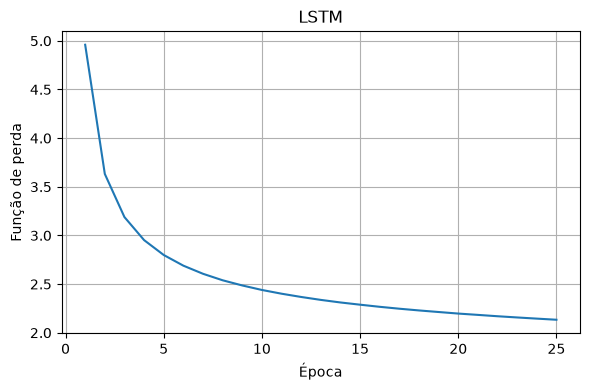

In [34]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, EPOCHS + 1), losses_lstm)
plt.xlabel("Época")
plt.ylabel("Função de perda")
plt.title("LSTM")
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. Geração de texto

Depois de treinado, o modelo pode gerar receitas novas. A geração é feita de modo auto-regressivo: o modelo recebe um prompt, prediz o próximo token, adiciona esse token ao prompt e repete o processo.

A escolha do próximo token pode ser determinística ou estocástica, dependendo da estratégia de amostragem.

### Classe `TextGenerator`

A célula a seguir define uma classe para gerar texto com o modelo treinado.

A geração ocorre em três etapas:

1. converter o prompt inicial em IDs;
2. obter a distribuição de probabilidade do próximo token;
3. escolher um token por amostragem com temperatura ou por modo guloso.

A temperatura controla a aleatoriedade:

- `temperature < 1`: distribuição mais concentrada;
- `temperature = 1`: distribuição original;
- `temperature > 1`: distribuição mais espalhada ("mais uniforme").

**Exemplo.** Suponha probabilidades para três tokens:

```text
    garlic: 0.70
    onion:  0.20
    salt:   0.10
```

Com temperatura baixa, `garlic` será escolhido com frequência ainda maior. Com temperatura alta, `onion` e `salt` terão mais chance, aumentando diversidade, mas também risco de incoerência.


In [35]:
class TextGenerator:
    """
    Gerador de texto auto-regressivo, a partir de um modelo treinado.

    Esta classe recebe um modelo que, dado um tensor de índices de tokens
    com shape [B, L], devolve logits [B, L, V]. A partir disso, permite
    gerar texto token a token, usando amostragem com temperatura ou modo
    guloso (greedy).

    Parameters
    ----------
    model : torch.nn.Module
        Modelo de linguagem treinado que recebe entradas [B, L] e retorna
        logits [B, L, V].
    itos : list of str
        Lista de mapeamento índice -> token (index-to-string).
    device : str or torch.device, optional
        Dispositivo onde o modelo será executado (por exemplo, "cpu" ou "cuda").
        (default = "cpu")
    """

    def __init__(self, model, itos, device="cpu"):
        self.model = model.to(device)                    # envia o modelo para o dispositivo (CPU ou GPU)
        self.itos = itos                                 # lista índice -> token
        self.stoi = {w: i for i, w in enumerate(itos)}   # dicionário token -> índice (string-to-index)
        self.device = device                             # armazena o dispositivo para uso na geração

    def sample_from(self, probs, temperature=1.0):
        """
        Amostra um índice de token a partir de uma distribuição de probabilidade,
        ajustando-a por uma temperatura.

        Parameters
        ----------
        probs : numpy.ndarray
            Vetor 1D com probabilidades sobre o vocabulário (soma ≈ 1).
        temperature : float, optional
            Fator de "temperatura" para ajustar a distribuição:
            - valores < 1.0 tornam a distribuição mais "aguda" (mais determinística);
            - valores > 1.0 tornam a distribuição mais "achatada" (mais aleatória).
            (default = 1.0)

        Returns
        -------
        idx : int
            Índice de token amostrado da distribuição ajustada.
        p : numpy.ndarray
            Vetor de probabilidades após o ajuste de temperatura e normalização.
        """
        # ajusta a temperatura: eleva as probabilidades à potência 1/temperature
        p = probs ** (1.0 / temperature)
        p = p / p.sum()                                  # renormaliza para que a soma volte a ser 1
        idx = np.random.choice(len(p), p=p)              # amostra um índice de acordo com a distribuição ajustada
        return idx, p

    def generate(self, start_prompt, max_tokens=100, temperature=1.0, greedy=False):
        """
        Gera texto a partir de um prompt inicial, usando o modelo treinado.

        A geração é feita token a token, até atingir max_tokens ou até que
        o token de padding (ID 0) seja gerado.

        Parameters
        ----------
        start_prompt : str
            Texto inicial (prompt) a partir do qual a geração será continuada.
        max_tokens : int, optional
            Número máximo de tokens na sequência gerada (incluindo os do prompt).
            (default = 100)
        temperature : float, optional
            Temperatura usada na amostragem:
            - ignorado se greedy=True;
            - quanto menor, mais determinística a amostragem.
            (default = 1.0)
        greedy : bool, optional
            Se True, utiliza estratégia gulosa (sempre escolhe o token de maior
            probabilidade no passo atual). Se False, utiliza amostragem com temperatura.
            (default = False)

        Returns
        -------
        list of dict
            Lista de dicionários com informações por passo de geração. Cada item contém:
            - "prompt": texto gerado até aquele passo;
            - "word_probs": vetor numpy com a distribuição de probabilidade sobre o vocabulário.
        """

        tokens = [self.stoi.get(tok, 1) for tok in start_prompt.lower().split()]    # converte o prompt inicial em índices; tokens fora do vocabulário recebem ID 1 (<UNK>)
        generated = tokens.copy()                                                   # sequência de índices gerada até o momento
        info = []                                                                   # lista para armazenar probabilidades em cada passo

        self.model.eval()                                                           # coloca o modelo em modo de avaliação

        with torch.no_grad():                                                       # desativa gradientes

            while len(generated) < max_tokens and generated[-1] != 0:               # continua gerando enquanto não atingir max_tokens e não for gerado o token <PAD> (ID 0)
                x = torch.tensor([generated], device=self.device)                   # cria tensor de entrada com shape [1, seq_len]
                logits = self.model(x)                                              # obtém logits do modelo: [1, seq_len, V]
                probs = F.softmax(logits[0, -1],                                    # pega logits do último passo de tempo [V]
                                   dim=-1).cpu().numpy()                            # converte para probabilidades no CPU como numpy array

                if greedy:
                    idx = int(probs.argmax())                                       # modo guloso: escolhe o índice de maior probabilidade
                    p = probs                                                       # mantém a distribuição original
                else:
                    idx, p = self.sample_from(probs, temperature)                   # modo estocástico: amostra usando temperatura


                info.append({                                                       # registra o prompt atual (em texto) e as probabilidades usadas nesse passo
                    "prompt": " ".join(self.itos[t] for t in generated),
                    "word_probs": p
                })

                generated.append(idx)                                               # adiciona o novo token gerado à sequência


        text = " ".join(self.itos[i] for i in generated)                            # converte a sequência final de índices de volta para texto
        mode = "GREEDY" if greedy else f"TEMP={temperature}"

        print(f"\nGenerated text ({mode}):\n{text}\n")                              # exibe o texto gerado na saída padrão

        return info                                                                 # retorna informações detalhadas de cada passo


def print_probs_pt(info, itos, top_k=5):
    """
    Mostra, para cada passo de geração, as top_k palavras mais prováveis
    de acordo com o vetor de probabilidades armazenado.

    Parameters
    ----------
    info : list of dict
        Lista retornada por TextGenerator.generate(), onde cada item contém:
        - "prompt": texto gerado até aquele passo;
        - "word_probs": vetor numpy com probabilidades sobre o vocabulário.
    itos : list of str
        Lista índice -> token (index-to-string) usada para mapear IDs de volta a palavras.
    top_k : int, optional
        Número de tokens mais prováveis a serem exibidos em cada passo.
        (default = 5)
    """
    for step in info:                                      # percorre cada passo registrado na geração
        prompt = step["prompt"]                            # texto corrente até aquele passo
        word_probs = step["word_probs"]                    # vetor numpy com probabilidade de cada token


        idx_sorted = np.argsort(word_probs)[::-1][:top_k]  # obtém os índices dos top_k tokens mais prováveis (ordem decrescente de probabilidade)
        p_sorted = word_probs[idx_sorted]                  # probabilidades correspondentes aos índices top_k

        print(f"\nPROMPT: {prompt}")
        for idx, p in zip(idx_sorted, p_sorted):           # percorre cada token entre os mais prováveis
            token = itos[idx]                              # converte índice em token de texto
            print(f"{token:<15} {p*100:6.2f}%")            # imprime token justificado e probabilidade em porcentagem
        print("--------\n")                                # separador visual entre passos

#### Preparação do gerador de texto

A célula a seguir escolhe o modelo treinado e cria o objeto `TextGenerator`.

O gerador recebe:

- o modelo LSTM;
- o vocabulário `itos`, para converter IDs em tokens;
- o dispositivo de execução.

**Exemplo.** Se o modelo gera o ID `25`, o gerador usa `ds.itos[25]` para recuperar a palavra correspondente e adicioná-la ao texto.

In [36]:
modelo = modelo_lstm
gen = TextGenerator(modelo, ds.itos, device=DEVICE)

### Geração com temperatura 1.0

A célula a seguir gera texto a partir do prompt:

```text
    recipe for roasted vegetables |
```

usando temperatura `1.0`, isto é, a distribuição predita pelo modelo sem torná-la artificialmente mais concentrada ou mais espalhada.

**Exemplo.** Se o modelo prediz:

```text
- with: 40%
- in: 30%
- and: 20%
```

a amostragem com temperatura 1.0 respeita essas probabilidades.

In [37]:
# gerar com temperatura = 1.0:
info = gen.generate("recipe for roasted vegetables | ", max_tokens=15, temperature=1.0)
print_probs_pt(info, ds.itos, top_k=3)


Generated text (TEMP=1.0):
recipe for roasted vegetables | finely chop parsley and parsley leaves in a 4 -


PROMPT: recipe for roasted vegetables |
preheat          40.43%
in               11.61%
mix               5.14%
--------


PROMPT: recipe for roasted vegetables | finely
chop             45.10%
grind            34.80%
grate            10.32%
--------


PROMPT: recipe for roasted vegetables | finely chop
garlic           12.91%
onion             7.11%
1                 4.06%
--------


PROMPT: recipe for roasted vegetables | finely chop parsley
and              30.93%
,                29.31%
.                14.46%
--------


PROMPT: recipe for roasted vegetables | finely chop parsley and
garlic            7.51%
in                4.20%
lemon             3.69%
--------


PROMPT: recipe for roasted vegetables | finely chop parsley and parsley
.                22.77%
in               21.59%
leaves           14.33%
--------


PROMPT: recipe for roasted vegetables | finely chop parsl

### Geração com temperatura 0.2

A célula a seguir gera texto com temperatura baixa, tornando a distribuição mais concentrada.

Isso tende a produzir texto mais previsível e conservador, pois tokens de maior probabilidade dominam a amostragem.

**Exemplo.** Se as probabilidades originais são:

```text
- with: 40%
- in: 30%
- and: 20%
```

após uma temperatura baixa, o token `with` pode se tornar muito mais dominante, diminuindo a diversidade.

In [38]:
# gerar com temperatura = 0.2 (mais determinístico):
info = gen.generate("recipe for roasted vegetables | ", max_tokens=15, temperature=0.2)
print_probs_pt(info, ds.itos, top_k=3)


Generated text (TEMP=0.2):
recipe for roasted vegetables | preheat oven to 400°f . butter 13x9x2 - inch glass


PROMPT: recipe for roasted vegetables |
preheat          99.80%
in                0.20%
mix               0.00%
--------


PROMPT: recipe for roasted vegetables | preheat
oven            100.00%
broiler           0.00%
the               0.00%
--------


PROMPT: recipe for roasted vegetables | preheat oven
to              100.00%
until             0.00%
rack              0.00%
--------


PROMPT: recipe for roasted vegetables | preheat oven to
400°f            67.08%
450°f            16.34%
350°f            14.85%
--------


PROMPT: recipe for roasted vegetables | preheat oven to 400°f
.               100.00%
with              0.00%
;                 0.00%
--------


PROMPT: recipe for roasted vegetables | preheat oven to 400°f .
place            59.06%
butter           19.74%
line              9.39%
--------


PROMPT: recipe for roasted vegetables | preheat oven to 400°f . bu

### Geração gulosa (`greedy`)

A célula a seguir usa geração determinística: em cada passo, escolhe sempre o token de maior probabilidade.

Essa estratégia elimina aleatoriedade, mas pode gerar textos repetitivos ou pouco criativos.

**Exemplo.** Se o modelo prediz:

```text
- with: 40%
- in: 30%
- and: 20%
```

o modo guloso sempre escolherá `with`, independentemente das demais probabilidades.

In [39]:
# gerar determinísticamente (forma gulosa - greedy):
info = gen.generate("recipe for roasted vegetables | ", max_tokens=15, temperature=1.0, greedy=True)
print_probs_pt(info, ds.itos, top_k=3)


Generated text (GREEDY):
recipe for roasted vegetables | preheat oven to 400°f . place chicken in large bowl


PROMPT: recipe for roasted vegetables |
preheat          40.43%
in               11.61%
mix               5.14%
--------


PROMPT: recipe for roasted vegetables | preheat
oven             84.28%
broiler           7.86%
the               5.89%
--------


PROMPT: recipe for roasted vegetables | preheat oven
to               99.70%
until             0.12%
rack              0.05%
--------


PROMPT: recipe for roasted vegetables | preheat oven to
400°f            23.68%
450°f            17.85%
350°f            17.51%
--------


PROMPT: recipe for roasted vegetables | preheat oven to 400°f
.                95.44%
with              1.22%
;                 1.14%
--------


PROMPT: recipe for roasted vegetables | preheat oven to 400°f .
place             7.90%
butter            6.35%
line              5.47%
--------


PROMPT: recipe for roasted vegetables | preheat oven to 400°f . pla

## 8. Avaliação

A avaliação mede quão bem o modelo prediz tokens em dados não usados no treinamento.

A métrica usada é a perplexity, muito comum em modelos de linguagem. Ela pode ser interpretada como uma medida do grau de incerteza médio do modelo ao predizer o próximo token.

### Cálculo da perplexity

A célula a seguir define `compute_perplexity`, que calcula a entropia cruzada média por token no conjunto de teste e depois aplica:

$$
\text{perplexity}=\exp(\text{entropia cruzada média}).
$$

Quanto menor a perplexity, melhor o modelo está prevendo os próximos tokens.

**Exemplo.** Se a entropia cruzada média por token é $2$, então:

$$
\text{perplexity}=e^2 \approx 7.39.
$$

Isso pode ser interpretado, aproximadamente, como se o modelo tivesse que escolher entre 7.39 alternativas plausíveis em média a cada passo de predição.

In [40]:
def compute_perplexity(model, data_loader):
    """
    Calcula a perplexidade de um modelo auto-regressivo em um conjunto de dados.

    A função percorre todos os lotes do data_loader, acumula a soma do NLL
    sobre todos os tokens não-PAD e, ao final, computa:

        avg_nll = NLL média por token
        perplexity = exp(avg_nll)

    Parameters
    ----------
    model : torch.nn.Module
        Modelo já treinado que recebe tensores [B, L] e retorna logits [B, L, V].
    data_loader : torch.utils.data.DataLoader
        DataLoader com lotes (x_batch, y_batch) usados para avaliação.

    Returns
    -------
    tuple of float
        avg_nll : NLL média por token não-PAD.
        ppl     : perplexidade correspondente (exp(avg_nll)).
    """

    model.eval()                                               # coloca o modelo em modo de avaliação
    total_loss = torch.tensor(0.0, device=DEVICE)              # acumula a soma da NLL sobre todos os tokens não-PAD
    total_tokens = torch.tensor(0.0, device=DEVICE)            # acumula o número total de tokens não-PAD usados no cálculo

    loss_fn = nn.CrossEntropyLoss(ignore_index=0,              # entropia cruzada ignorando o token <PAD> (ID 0)
                                  reduction="sum")             # reduction="sum": retorna a soma da NLL sobre os tokens válidos do lote

    with torch.no_grad():                                      # bloco sem cálculo de gradiente (apenas avaliação)
        for x_batch, y_batch in data_loader:                   # percorre todos os lotes (x, y) do data_loader
            x_batch = x_batch.to(DEVICE)                       # move o lote de entradas para o dispositivo
            y_batch = y_batch.to(DEVICE)                       # move o lote de alvos para o dispositivo

            logits = model(x_batch)                            # obtém logits do modelo: [B, L, V]

            loss = compute_nll(logits, y_batch, loss_fn)       # NLL somada sobre todos os tokens não-PAD do lote (escalares)

            total_loss += loss                                 # acumula a soma das perdas de todos os lotes
            total_tokens += (y_batch != 0).sum()               # acumula quantos tokens não são <PAD> (ID 0) em todo o data_loader

    avg_nll = total_loss / total_tokens                        # NLL média por token não-PAD em todo o conjunto avaliado
    ppl = torch.exp(avg_nll)                                   # perplexidade = exp(NLL média por token)

    return avg_nll.item(), ppl.item()                          # devolve valores escalares em float (para impressão / logging)

### Avaliação da LSTM no conjunto de teste

Esta célula calcula e imprime a NLL média e a perplexity da LSTM nos dados de teste.

**Exemplo.** Uma saída como:

```text
    - LSTM NLL: 3.20
    - LSTM PPL: 24.53
```

indica que, em média, o modelo ainda possui incerteza equivalente a cerca de 24 tokens plausíveis por posição.

In [41]:
test_nll_lstm, test_ppl_lstm = compute_perplexity(modelo_lstm, test_dl)
print(f"LSTM NLL: {test_nll_lstm:.4f}, LSTM PPL: {test_ppl_lstm:.2f}")

LSTM NLL: 2.3532, LSTM PPL: 10.52


# Tarefa (em duplas)

**Investigar o efeito da camada recorrente (LSTM, GRU e RNN clássica) e da temperatura de amostragem em um modelo auto-regressivo de texto treinado com as receitas do *Epicurious***

Utilize o código acima como base e adapte-o para o seguinte problema:

1. Implemente uma
[*Gated Recurrent Unit*, GRU](https://en.wikipedia.org/wiki/Gated_recurrent_unit) e uma RNN clássica, criando as classes `RNN_GRU` e `RNN_Classica` a partir de `RNN_LSTM`. Troque apenas a camada recorrente, usando [`nn.GRU`](https://docs.pytorch.org/docs/stable/generated/torch.nn.GRU.html) e [`nn.RNN`](https://docs.pytorch.org/docs/stable/generated/torch.nn.RNN.html), respectivamente, e mantenha a camada de *embedding* e a camada linear de saída. No `forward`, basta chamar a nova camada no lugar de `self.lstm` (por exemplo, `output, _ = self.gru(emb)`):

```python
self.gru = nn.GRU(input_size=embedding_dim, hidden_size=hidden_size, batch_first=True)                       # substitui self.lstm em RNN_GRU
self.rnn = nn.RNN(input_size=embedding_dim, hidden_size=hidden_size, nonlinearity="tanh", batch_first=True)  # substitui self.lstm em RNN_Classica
```

Instancie `modelo_gru` e `modelo_rnn` com os mesmos `VOCAB_SIZE`, `EMBEDDING_DIM` e `N_UNITS` da LSTM. Execute `torch.manual_seed(42)` imediatamente antes de instanciar cada modelo, inclusive `modelo_lstm` no código base.

2. A LSTM do código acima é a **configuração base** e serve de referência para todas as comparações. Treine `modelo_gru` e `modelo_rnn` com a mesma função `train_autoregressive_model`, guardando as perdas em `losses_gru` e `losses_rnn`. Em seguida, adapte a célula da curva de perda para plotar `losses_lstm`, `losses_gru` e `losses_rnn` no mesmo gráfico, com legenda.

3. Repita, para a LSTM, para a GRU e para a RNN clássica, as três gerações do código base com o prompt `"recipe for roasted vegetables | "` e `max_tokens=25` - temperatura $\in \{1.5, 1.0, 0.2\}$ e modo guloso [*greedy*] -, exibindo as três palavras mais prováveis em cada passo com `print_probs_pt(info, ds.itos, top_k=3)`.

   Obs.: crie um `TextGenerator` para cada modelo (por exemplo, `gen_gru` e `gen_rnn`).


4. Calcule a NLL média e a *perplexity* da GRU e da RNN clássica no conjunto de teste com `compute_perplexity`, como feito para a LSTM, e reúna os resultados dos três modelos em uma tabela.

**Os três modelos devem ser treinados e avaliados com os mesmos dados (`train_dl`, `test_dl` e o vocabulário `ds.itos`), os mesmos hiperparâmetros do código base (`EMBEDDING_DIM=100`, `N_UNITS=128`, `BATCH_SIZE=32`, `Adam` com `LEARNING_RATE=1e-3` e `EPOCHS=25`) e a mesma semente aleatória.** Altere apenas a camada recorrente; se precisar alterar qualquer outro item, registre e justifique a alteração no relatório.

**Entregáveis:**

Os entregáveis são **cumulativos ao longo da Unidade 1**. Ao final da unidade,
você entregará **apenas dois arquivos**, reunindo todos os laboratórios:

1. **Notebook** (`.ipynb`) — um único notebook com o código de todos os
   laboratórios da unidade, cada um em sua própria seção, na ordem em que foram
   realizados.

   O notebook deve **executar do início ao fim sem erros**, em um kernel novo,
   com *Restart & Run All*. Antes de entregar, execute-o dessa forma e confirme
   que todas as células rodam na ordem em que aparecem e que as saídas exibidas
   correspondem a essa execução. Notebooks que não executarem por completo serão
   penalizados.

2. **Relatório** (`.pdf`) — um único PDF, também organizado em seções, uma por
   laboratório.

Este laboratório corresponde à **Seção 5 — Modelos auto-regressivos com RNNs**, que deve conter:

- **Setup**: dados utilizados (receitas do *Epicurious* no formato
  `Recipe for <título> | <instruções>`, normalização aplicada ao texto, tamanho
  do vocabulário, comprimento das sequências, divisão entre treino e teste e
  tamanho do lote), arquiteturas das três redes (*embedding*, camada recorrente
  e camada linear de saída) e hiperparâmetros (função de perda, otimizador, taxa
  de aprendizado, dimensão do *embedding*, tamanho do estado oculto e número de
  épocas).
- **Resultados**:
  - curvas de perda de treinamento da LSTM, da GRU e da RNN clássica no mesmo
    gráfico;
  - para cada modelo, as três palavras mais prováveis, com suas probabilidades,
    no primeiro passo após o prompt (item 3);
  - tabela com a NLL média e a perplexidade de cada modelo no conjunto de teste.
- **Análise**: texto breve (5-10 linhas) discutindo qual modelo obteve a menor *perplexity* e se essa ordem é coerente com as curvas de perda e com a qualidade das receitas geradas; como a temperatura afeta a coerência e a diversidade do texto (se aparecem repetições no modo guloso e em temperaturas baixas, ou perda de coerência em temperaturas altas) e se o efeito é o mesmo nos três modelos; e o que os resultados sugerem sobre a LSTM e a GRU na modelagem de dependências longas, em comparação com a RNN clássica.

Nos próximos laboratórios da unidade, acrescente uma nova seção a cada arquivo,
preservando as anteriores.

O relatório **não** deve conter código.

A entrega é **única por grupo**. Identifique os integrantes no início do
notebook e na primeira página do relatório.